### Smart Workplace Mask Compliance Monitor

#### ~Face Detection using YOLOv8
#### ~Mask Classification using EfficientNetB0

### Import libraries

In [2]:
import cv2
import numpy as np
import tensorflow as tf

from ultralytics import YOLO
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, Model

###  load yolo model (Face Detection)

In [3]:
# Use pretrained YOLOv8
yolo_model = YOLO("yolov8n.pt")

### Build EfficientNet Model (Mask Classification)

In [4]:
baseModel = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

baseModel.trainable = False

x = baseModel.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)

mask_model = Model(inputs=baseModel.input, outputs=output)

mask_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### loading dataset (from XML)

In [5]:
import os
import xml.etree.ElementTree as ET

img_path = r"C:\Users\priya\Smart Workplace Mask Compliance Monitor\images"
label_path = r"C:\Users\priya\Smart Workplace Mask Compliance Monitor\annotations"

data = []
labels = []

for file in os.listdir(label_path):
    if not file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(label_path, file))
    root = tree.getroot()

    img_file = file.replace(".xml", ".png")
    img = cv2.imread(os.path.join(img_path, img_file))

    if img is None:
        continue

    for obj in root.findall("object"):
        label = obj.find("name").text

        bbox = obj.find("bndbox")
        x1 = int(bbox.find("xmin").text)
        y1 = int(bbox.find("ymin").text)
        x2 = int(bbox.find("xmax").text)
        y2 = int(bbox.find("ymax").text)

        face = img[y1:y2, x1:x2]

        if face.size == 0:
            continue

        face = cv2.resize(face, (224, 224))
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

        data.append(face)
        labels.append(0 if label == "with_mask" else 1)

X = np.array(data)
y = np.array(labels)

print("Loaded:", X.shape)

Loaded: (4072, 224, 224, 3)


In [6]:
X = preprocess_input(X)

### Class Imbalance Graph

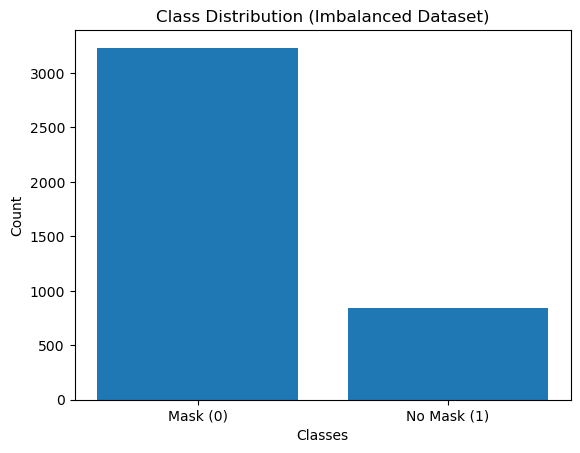

In [7]:
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)

plt.figure()
plt.bar(["Mask (0)", "No Mask (1)"], counts)
plt.title("Class Distribution (Imbalanced Dataset)")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

### Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Handle imbalance

In [12]:
class_weight = {0: 1, 1: 4}

### Balance graph

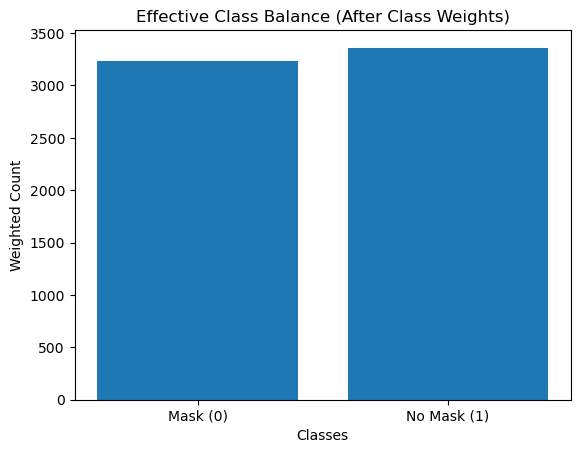

In [9]:
balanced_counts = [counts[0]*1, counts[1]*4]

plt.figure()
plt.bar(["Mask (0)", "No Mask (1)"], balanced_counts)
plt.title("Effective Class Balance (After Class Weights)")
plt.xlabel("Classes")
plt.ylabel("Weighted Count")
plt.show()

 ### Train Model

In [8]:
history = mask_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=16,
    class_weight=class_weight
)

Epoch 1/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.7568 - loss: 0.8166 - val_accuracy: 0.7865 - val_loss: 0.4128
Epoch 2/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8339 - loss: 0.5962 - val_accuracy: 0.9043 - val_loss: 0.2612
Epoch 3/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.8692 - loss: 0.5052 - val_accuracy: 0.9129 - val_loss: 0.2438
Epoch 4/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.8901 - loss: 0.4345 - val_accuracy: 0.9178 - val_loss: 0.2202
Epoch 5/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.8941 - loss: 0.4023 - val_accuracy: 0.9276 - val_loss: 0.1994
Epoch 6/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.9070 - loss: 0.3738 - val_accuracy: 0.9227 - val_loss: 0.2003
Epoch 7/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.9116 - loss: 0.3484 - val_accuracy: 0.9067 - val_loss: 0.2200
Epoch 8/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.9189 - loss: 0.3279 - val_accu

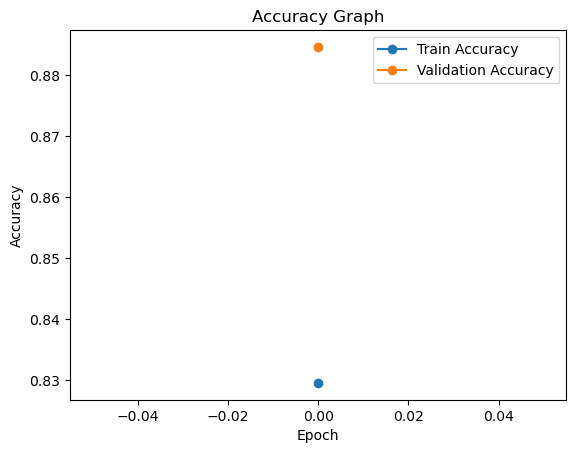

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Save Model

In [6]:
from tensorflow.keras.models import load_model
mask_model = load_model("final_mask_model.keras")

### Confusion Matrix

26/26 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step 


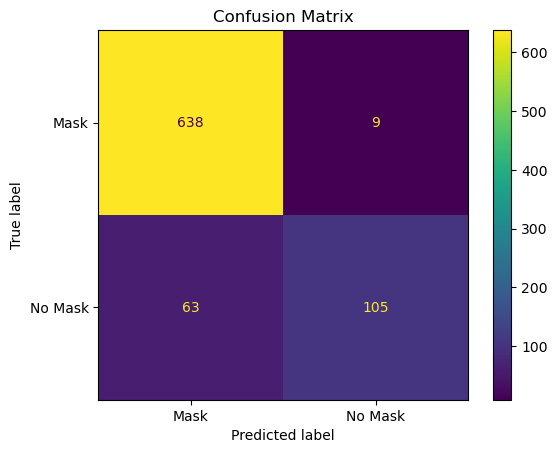

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = (mask_model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mask", "No Mask"])
disp.plot()

plt.title("Confusion Matrix")
plt.show()

### detection with images 

In [4]:
import cv2
import numpy as np
from ultralytics import YOLO
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load models
yolo_model = YOLO("yolov8n.pt")
mask_model = load_model("final_mask_model.keras")

def detect_image(path):
    img = cv2.imread(path)

    # Safety check
    if img is None:
        print("Image not found:", path)
        return

    results = yolo_model(img)

    for r in results:

        # Loop through boxes + class
        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):

            # ✔ Only PERSON
            if int(cls) != 0:
                continue

            x1, y1, x2, y2 = map(int, box.cpu().numpy())

            # ✔ Crop upper half (face region)
            face = img[y1:y1 + (y2 - y1)//2, x1:x2]

            if face.size == 0:
                continue

            # Preprocess
            face = cv2.resize(face, (224, 224))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face = preprocess_input(face)
            face = np.expand_dims(face, axis=0)

            # Prediction
            pred = mask_model.predict(face)[0][0]
            print(f"{path} Prediction:", pred)

            # ✔ Better threshold
            label = "No Mask" if pred > 0.6 else "Mask"
            color = (0, 0, 255) if pred > 0.6 else (0, 255, 0)

            # Draw box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Show result
    cv2.imshow(path, img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()



detect_image(r"C:\Users\priya\Smart Workplace Mask Compliance Monitor\images\maksssksksss141.png")
detect_image(r"C:\Users\priya\Smart Workplace Mask Compliance Monitor\images\maksssksksss239.png")


0: 448x640 3 persons, 958.2ms
Speed: 245.7ms preprocess, 958.2ms inference, 26.9ms postprocess per image at shape (1, 3, 448, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
C:\Users\priya\Smart Workplace Mask Compliance Monitor\images\maksssksksss141.png Prediction: 0.07728628
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
C:\Users\priya\Smart Workplace Mask Compliance Monitor\images\maksssksksss141.png Prediction: 0.03081643
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
C:\Users\priya\Smart Workplace Mask Compliance Monitor\images\maksssksksss141.png Prediction: 0.084756345

0: 640x512 2 persons, 1555.6ms
Speed: 55.8ms preprocess, 1555.6ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 512)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
C:\Users\priya\Smart Workplace Mask Compliance Monitor\images\maksssksksss239.png Prediction: 0.70036995
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
C:\Users\priya\Smart Workplace Mask Compliance Monitor\images\maksssksksss239.png Prediction: 0.015394558


### detection with webcam

In [5]:
import cv2
import numpy as np
from ultralytics import YOLO
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load models
yolo_model = YOLO("yolov8n.pt")
mask_model = load_model("final_mask_model.keras")

# Webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = yolo_model(frame)

    for r in results:

        # Loop through boxes + class
        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):

            # ✔ Only detect PERSON (class 0)
            if int(cls) != 0:
                continue

            x1, y1, x2, y2 = map(int, box.cpu().numpy())

            # ✔ Crop upper half (better face region)
            face = frame[y1:y1 + (y2 - y1)//2, x1:x2]

            if face.size == 0:
                continue

            # Preprocess
            face = cv2.resize(face, (224, 224))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face = preprocess_input(face)
            face = np.expand_dims(face, axis=0)

            # Prediction
            pred = mask_model.predict(face)[0][0]
            print("Prediction:", pred)   # Debug

            # ✔ Better threshold
            label = "No Mask" if pred > 0.6 else "Mask"
            color = (0, 0, 255) if pred > 0.6 else (0, 255, 0)

            # Draw box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.imshow("Mask Detection", frame)

    # ESC to exit
    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 911.8ms
Speed: 196.1ms preprocess, 911.8ms inference, 58.5ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Prediction: 0.6082045

0: 480x640 1 person, 1606.1ms
Speed: 379.3ms preprocess, 1606.1ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Prediction: 0.68454564

0: 480x640 1 person, 376.9ms
Speed: 5.2ms preprocess, 376.9ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Prediction: 0.67451555

0: 480x640 1 person, 343.7ms
Speed: 3.7ms preprocess, 343.7ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Prediction: 0.69944656

0: 480x640 1 person, 350.7ms
Speed: 3.3ms preprocess, 350.7ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Prediction: 0.8461956

0: 480x640 1 person, 344.1ms
Speed: 3.0ms pre

In [4]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = yolo_model(frame)

    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()

        for box in boxes:
            x1, y1, x2, y2 = map(int, box)

            face = frame[y1:y2, x1:x2]
            if face.size == 0:
                continue

            face = cv2.resize(face, (224, 224))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face = preprocess_input(face)
            face = np.expand_dims(face, axis=0)

            pred = mask_model.predict(face)[0][0]

            label = "No Mask" if pred > 0.5 else "Mask"
            color = (0,0,255) if pred > 0.5 else (0,255,0)

            cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
            cv2.putText(frame, label, (x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.imshow("Mask Detection", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 668.2ms
Speed: 150.7ms preprocess, 668.2ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step

0: 480x640 1 person, 543.0ms
Speed: 2.7ms preprocess, 543.0ms inference, 3.0ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

0: 480x640 1 person, 372.3ms
Speed: 3.0ms preprocess, 372.3ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step

0: 480x640 1 person, 363.5ms
Speed: 6.5ms preprocess, 363.5ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

0: 480x640 1 person, 354.8ms
Speed: 3.1ms preprocess, 354.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

0: 480x640 1 person, 1 tie, 348.8ms
Speed: 4.1ms preprocess, 348.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [7]:
import cv2
import numpy as np
from ultralytics import YOLO
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

yolo_model = YOLO("yolov8n.pt")
mask_model = load_model("final_mask_model.keras")

cap = cv2.VideoCapture(0)
mask_count = 0
no_mask_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    mask_count = 0
    no_mask_count = 0

    results = yolo_model(frame)

    for r in results:
        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):
            if int(cls) != 0:
                continue

            x1, y1, x2, y2 = map(int, box.cpu().numpy())
            face = frame[y1:y1 + (y2 - y1)//2, x1:x2]
            if face.size == 0:
                continue

            face = cv2.resize(face, (224, 224))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face = preprocess_input(face)
            face = np.expand_dims(face, axis=0)

            pred = mask_model.predict(face)[0][0]
            label = "No Mask" if pred > 0.6 else "Mask"
            color = (0, 0, 255) if pred > 0.6 else (0, 255, 0)

            if label == "Mask":
                mask_count += 1
            else:
                no_mask_count += 1

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Dashboard Panel
    panel = np.zeros((frame.shape[0], 300, 3), dtype=np.uint8)
    panel[:] = (30, 30, 30)

    cv2.putText(panel, "MASK MONITOR", (20, 40),
                cv2.FONT_HERSHEY_DUPLEX, 0.8, (255, 255, 255), 2)
    cv2.line(panel, (10, 55), (290, 55), (100, 100, 100), 1)

    cv2.putText(panel, "With Mask:", (20, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)
    cv2.putText(panel, str(mask_count), (220, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.putText(panel, "No Mask:", (20, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)
    cv2.putText(panel, str(no_mask_count), (220, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    cv2.line(panel, (10, 175), (290, 175), (100, 100, 100), 1)

    # Status alert — FIXED INDENTATION
    if no_mask_count > 0:
        status_text = "!! VIOLATION"
        status_color = (0, 0, 255)
    else:
        status_text = "ALL CLEAR"
        status_color = (0, 255, 0)

    cv2.putText(panel, "Status:", (20, 220),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)
    cv2.putText(panel, status_text, (20, 260),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, status_color, 2)

    cv2.putText(panel, "Press ESC to exit", (20, frame.shape[0] - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150, 150, 150), 1)

    combined = np.hstack([frame, panel])
    cv2.imshow("Smart Workplace Mask Compliance Monitor", combined)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 2 persons, 534.5ms
Speed: 26.7ms preprocess, 534.5ms inference, 36.3ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step

0: 480x640 2 persons, 437.2ms
Speed: 11.6ms preprocess, 437.2ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step

0: 480x640 1 person, 349.2ms
Speed: 3.2ms preprocess, 349.2ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step

0: 480x640 1 person, 351.5ms
Speed: 4.3ms preprocess, 351.5ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

0: 480x640 1 person, 346.7ms
Speed: 5.6ms preprocess, 346.7ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step

0: 480x640 1 person, 1 tie, 350.3ms
Speed: 3.2ms preprocess, 350.3ms inference, 2.